# VITS

In [1]:
# Torch imports
import torch
import torch.utils.data
from torch import nn
from torch.nn import functional as F
from torch.nn import Conv1d, ConvTranspose1d, Conv2d
from torch.nn.utils import weight_norm, remove_weight_norm, spectral_norm

import math
import soundfile as sf
import copy
import numpy as np
# import os
# import random
from IPython.display import display, Audio

# Spectrogram creation
# import librosa
# import librosa.util as librosa_util
# from librosa.util import normalize, pad_center, tiny
# from scipy.signal import get_window
# from scipy.io.wavfile import read
from librosa.filters import mel as librosa_mel_fn

# Import custom modules
import commons
import modules
import attentions
import utils
from commons import init_weights, get_padding

from text.symbols import symbols
from text import text_to_sequence
from utils import load_wav_to_torch
# from mel_processing import mel_spectrogram_torch, spectrogram_torch, spec_to_mel_torch

from utils import HParams

In [2]:
def get_text(text, hps):
    text_norm = text_to_sequence(text, hps.data.text_cleaners)
    if hps.data.add_blank:
        text_norm = commons.intersperse(text_norm, 0)
    text_norm = torch.LongTensor(text_norm)
    return text_norm

In [3]:
def plot_spectrogram(spectrogram, text=None, x_label="Time", y_label="Value", figsize=(16, 4)):
    if isinstance(spectrogram, torch.Tensor):
        spectrogram = spectrogram.cpu().detach().numpy()
    if len(spectrogram.shape) > 2:
        spectrogram = spectrogram[0]
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(spectrogram, aspect="auto", origin="lower",
                   interpolation='none')
    if text:
        plt.title(text)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.colorbar(im, ax=ax, use_gridspec=True)
    
    fig.canvas.draw()
    plt.show()

    return

<img src="images/fig_1a.png" width="70%">
<img src="images/fig_1b.png" width="70%">

# Spec

In [4]:
MAX_WAV_VALUE = 32768.0


def dynamic_range_compression_torch(x, C=1, clip_val=1e-5):
    """
    PARAMS
    ------
    C: compression factor
    """
    return torch.log(torch.clamp(x, min=clip_val) * C)


def dynamic_range_decompression_torch(x, C=1):
    """
    PARAMS
    ------
    C: compression factor used to compress
    """
    return torch.exp(x) / C


def spectral_normalize_torch(magnitudes):
    output = dynamic_range_compression_torch(magnitudes)
    return output


def spectral_de_normalize_torch(magnitudes):
    output = dynamic_range_decompression_torch(magnitudes)
    return output


mel_basis = {}
hann_window = {}


def spectrogram_torch(y, n_fft, sampling_rate, hop_size, win_size, center=False):
    if torch.min(y) < -1.:
        print('min value is ', torch.min(y))
    if torch.max(y) > 1.:
        print('max value is ', torch.max(y))

    global hann_window
    dtype_device = str(y.dtype) + '_' + str(y.device)
    wnsize_dtype_device = str(win_size) + '_' + dtype_device
    if wnsize_dtype_device not in hann_window:
        hann_window[wnsize_dtype_device] = torch.hann_window(win_size).to(dtype=y.dtype, device=y.device)

    y = torch.nn.functional.pad(y.unsqueeze(1), (int((n_fft-hop_size)/2), int((n_fft-hop_size)/2)), mode='reflect')
    y = y.squeeze(1)

    spec = torch.stft(y, n_fft, hop_length=hop_size, win_length=win_size, window=hann_window[wnsize_dtype_device],
                      center=center, pad_mode='reflect', normalized=False, onesided=True, return_complex=True)

    spec = torch.sqrt(spec.pow(2) + 1e-6).float()
    return spec


def spec_to_mel_torch(spec, n_fft, num_mels, sampling_rate, fmin, fmax):
    global mel_basis
    dtype_device = str(spec.dtype) + '_' + str(spec.device)
    fmax_dtype_device = str(fmax) + '_' + dtype_device
    if fmax_dtype_device not in mel_basis:
        mel = librosa_mel_fn(sr=sampling_rate, n_fft=n_fft, n_mels=num_mels, fmin=fmin, fmax=fmax)
        mel_basis[fmax_dtype_device] = torch.from_numpy(mel).to(dtype=spec.dtype, device=spec.device)
    spec = torch.matmul(mel_basis[fmax_dtype_device], spec)
    spec = spectral_normalize_torch(spec)
    return spec


def mel_spectrogram_torch(y, n_fft, num_mels, sampling_rate, hop_size, win_size, fmin, fmax, center=False):
    if torch.min(y) < -1.:
        print('min value is ', torch.min(y))
    if torch.max(y) > 1.:
        print('max value is ', torch.max(y))

    global mel_basis, hann_window
    dtype_device = str(y.dtype) + '_' + str(y.device)
    fmax_dtype_device = str(fmax) + '_' + dtype_device
    wnsize_dtype_device = str(win_size) + '_' + dtype_device
    if fmax_dtype_device not in mel_basis:
        mel = librosa_mel_fn(sampling_rate, n_fft, num_mels, fmin, fmax)
        mel_basis[fmax_dtype_device] = torch.from_numpy(mel).to(dtype=y.dtype, device=y.device)
    if wnsize_dtype_device not in hann_window:
        hann_window[wnsize_dtype_device] = torch.hann_window(win_size).to(dtype=y.dtype, device=y.device)

    y = torch.nn.functional.pad(y.unsqueeze(1), (int((n_fft-hop_size)/2), int((n_fft-hop_size)/2)), mode='reflect')
    y = y.squeeze(1)

    spec = torch.stft(y, n_fft, hop_length=hop_size, win_length=win_size, window=hann_window[wnsize_dtype_device],
                      center=center, pad_mode='reflect', normalized=False, onesided=True, return_complex=True)

    spec = torch.sqrt(spec.pow(2) + 1e-6).float()

    spec = torch.matmul(mel_basis[fmax_dtype_device], spec)
    spec = spectral_normalize_torch(spec)

    return spec

# Model architecture

## HIFI GAN

In [5]:
class Generator(torch.nn.Module):
    def __init__(self, initial_channel, resblock, resblock_kernel_sizes, resblock_dilation_sizes, upsample_rates, upsample_initial_channel, upsample_kernel_sizes, gin_channels=0):
        super(Generator, self).__init__()
        self.num_kernels = len(resblock_kernel_sizes)
        self.num_upsamples = len(upsample_rates)
        self.conv_pre = Conv1d(initial_channel, upsample_initial_channel, 7, 1, padding=3)
        resblock = modules.ResBlock1 if resblock == '1' else modules.ResBlock2

        self.ups = nn.ModuleList()
        for i, (u, k) in enumerate(zip(upsample_rates, upsample_kernel_sizes)):
            self.ups.append(weight_norm(
                ConvTranspose1d(upsample_initial_channel//(2**i), upsample_initial_channel//(2**(i+1)),
                                k, u, padding=(k-u)//2)))

        self.resblocks = nn.ModuleList()
        for i in range(len(self.ups)):
            ch = upsample_initial_channel//(2**(i+1))
            for j, (k, d) in enumerate(zip(resblock_kernel_sizes, resblock_dilation_sizes)):
                self.resblocks.append(resblock(ch, k, d))

        self.conv_post = Conv1d(ch, 1, 7, 1, padding=3, bias=False)
        self.ups.apply(init_weights)

        if gin_channels != 0:
            self.cond = nn.Conv1d(gin_channels, upsample_initial_channel, 1)

    def forward(self, x, g=None):
        x = self.conv_pre(x)
        if g is not None:
          x = x + self.cond(g)

        for i in range(self.num_upsamples):
            x = F.leaky_relu(x, modules.LRELU_SLOPE)
            x = self.ups[i](x)
            xs = None
            for j in range(self.num_kernels):
                if xs is None:
                    xs = self.resblocks[i*self.num_kernels+j](x)
                else:
                    xs += self.resblocks[i*self.num_kernels+j](x)
            x = xs / self.num_kernels
        x = F.leaky_relu(x)
        x = self.conv_post(x)
        x = torch.tanh(x)

        return x

    def remove_weight_norm(self):
        print('Removing weight norm...')
        for l in self.ups:
            remove_weight_norm(l)
        for l in self.resblocks:
            l.remove_weight_norm()

In [6]:
class DiscriminatorS(torch.nn.Module):
    def __init__(self, use_spectral_norm=False):
        super(DiscriminatorS, self).__init__()
        norm_f = weight_norm if use_spectral_norm == False else spectral_norm
        self.convs = nn.ModuleList([
            norm_f(Conv1d(1, 16, 15, 1, padding=7)),
            norm_f(Conv1d(16, 64, 41, 4, groups=4, padding=20)),
            norm_f(Conv1d(64, 256, 41, 4, groups=16, padding=20)),
            norm_f(Conv1d(256, 1024, 41, 4, groups=64, padding=20)),
            norm_f(Conv1d(1024, 1024, 41, 4, groups=256, padding=20)),
            norm_f(Conv1d(1024, 1024, 5, 1, padding=2)),
        ])
        self.conv_post = norm_f(Conv1d(1024, 1, 3, 1, padding=1))

    def forward(self, x):
        fmap = []

        for l in self.convs:
            x = l(x)
            x = F.leaky_relu(x, modules.LRELU_SLOPE)
            fmap.append(x)
        x = self.conv_post(x)
        fmap.append(x)
        x = torch.flatten(x, 1, -1)

        return x, fmap

In [7]:
class DiscriminatorP(torch.nn.Module):
    def __init__(self, period, kernel_size=5, stride=3, use_spectral_norm=False):
        super(DiscriminatorP, self).__init__()
        self.period = period
        self.use_spectral_norm = use_spectral_norm
        norm_f = weight_norm if use_spectral_norm == False else spectral_norm
        self.convs = nn.ModuleList([
            norm_f(Conv2d(1, 32, (kernel_size, 1), (stride, 1), padding=(get_padding(kernel_size, 1), 0))),
            norm_f(Conv2d(32, 128, (kernel_size, 1), (stride, 1), padding=(get_padding(kernel_size, 1), 0))),
            norm_f(Conv2d(128, 512, (kernel_size, 1), (stride, 1), padding=(get_padding(kernel_size, 1), 0))),
            norm_f(Conv2d(512, 1024, (kernel_size, 1), (stride, 1), padding=(get_padding(kernel_size, 1), 0))),
            norm_f(Conv2d(1024, 1024, (kernel_size, 1), 1, padding=(get_padding(kernel_size, 1), 0))),
        ])
        self.conv_post = norm_f(Conv2d(1024, 1, (3, 1), 1, padding=(1, 0)))

    def forward(self, x):
        fmap = []

        # 1d to 2d
        b, c, t = x.shape
        if t % self.period != 0: # pad first
            n_pad = self.period - (t % self.period)
            x = F.pad(x, (0, n_pad), "reflect")
            t = t + n_pad
        x = x.view(b, c, t // self.period, self.period)

        for l in self.convs:
            x = l(x)
            x = F.leaky_relu(x, modules.LRELU_SLOPE)
            fmap.append(x)
        x = self.conv_post(x)
        fmap.append(x)
        x = torch.flatten(x, 1, -1)

        return x, fmap

In [8]:
class MultiPeriodDiscriminator(torch.nn.Module):
    def __init__(self, use_spectral_norm=False):
        super(MultiPeriodDiscriminator, self).__init__()
        periods = [2,3,5,7,11]

        discs = [DiscriminatorS(use_spectral_norm=use_spectral_norm)]
        discs = discs + [DiscriminatorP(i, use_spectral_norm=use_spectral_norm) for i in periods]
        self.discriminators = nn.ModuleList(discs)

    def forward(self, y, y_hat):
        y_d_rs = []
        y_d_gs = []
        fmap_rs = []
        fmap_gs = []
        for i, d in enumerate(self.discriminators):
            y_d_r, fmap_r = d(y)
            y_d_g, fmap_g = d(y_hat)
            y_d_rs.append(y_d_r)
            y_d_gs.append(y_d_g)
            fmap_rs.append(fmap_r)
            fmap_gs.append(fmap_g)

        return y_d_rs, y_d_gs, fmap_rs, fmap_gs

## VITS modules

### Flow blocks

In [9]:
class ResidualCouplingBlock(nn.Module):
  def __init__(self,
      channels,
      hidden_channels,
      kernel_size,
      dilation_rate,
      n_layers,
      n_flows=4,
      gin_channels=0):
    super().__init__()
    self.channels = channels
    self.hidden_channels = hidden_channels
    self.kernel_size = kernel_size
    self.dilation_rate = dilation_rate
    self.n_layers = n_layers
    self.n_flows = n_flows
    self.gin_channels = gin_channels

    self.flows = nn.ModuleList()
    for i in range(n_flows):
      self.flows.append(ResidualCouplingLayer(channels, hidden_channels, kernel_size, dilation_rate, n_layers, gin_channels=gin_channels, mean_only=True))
      self.flows.append(Flip())

  def forward(self, x, x_mask, g=None, reverse=False):
    if not reverse:
      for flow in self.flows:
        x, _ = flow(x, x_mask, g=g, reverse=reverse)
    else:
      for flow in reversed(self.flows):
        x = flow(x, x_mask, g=g, reverse=reverse)
    return x

#### ResidualCouplingLayer
As input we have $x$ of shape $[B \times d \times T]$, we divide $x$ into $x_0$ and $x_1$, where $x_0 = x_{1:d/2}$, $x_1 = x_{d/2+1:d}$

$$
\text{Direct:}
\begin{cases} 
	{\color{violet}\mathbf{\tilde{x}}_0} = {\color{teal}\mathbf{x}_0}; \\ 
	{\color{violet}\mathbf{\tilde{x}}_1} = {\color{teal}\mathbf{x}_1} \odot \mathbf{\sigma}_{\mathbf{\theta}}({\color{teal}\mathbf{x}_0}) + \mathbf{\mu}_{\mathbf{\theta}}({\color{teal}\mathbf{x}_0})
\end{cases}  \\
\text{Inverse:}
\begin{cases} 
	{\color{teal}\mathbf{x}_0} = {\color{violet}\mathbf{\tilde{x}}_0}; \\ 
	{\color{teal}\mathbf{x}_1} = \left({\color{violet}\mathbf{\tilde{x}}_1} - \mathbf{\mu}_{\mathbf{\theta}}({\color{violet}\mathbf{\tilde{x}}_1}) \right) \odot \frac{1}{\mathbf{\sigma}_{\mathbf{\theta}}({\color{violet}\mathbf{\tilde{x}}_1})}
\end{cases} \\
$$

$$
\text{Determinant:}
\large
\det \left( \frac{\partial \mathbf{\tilde{x}}}{\partial \mathbf{x}} \right)  = \det 
\begin{pmatrix}
	\frac{\partial \mathbf{\tilde{x}}_0}{\partial \mathbf{x}_0} &  \frac{\partial \mathbf{\tilde{x}}_0}{\partial \mathbf{x}_1} \\
	\\
	\frac{\partial \mathbf{\tilde{x}}_1}{\partial \mathbf{x}_0} & \frac{\partial \mathbf{\tilde{x}}_1}{\partial \mathbf{x}_1}
\end{pmatrix} = \det 
\begin{pmatrix}
	\mathbf{I}_d & 0 \\ \\
	\frac{\partial \mathbf{\tilde{x}}_1}{\partial \mathbf{x}_0} & \text{diag}({\mathbf{\sigma}_{\mathbf{\theta}}(\mathbf{x}_0)})
\end{pmatrix}
$$

In [10]:
class ResidualCouplingLayer(nn.Module):
    def __init__(self,
                 channels,
                 hidden_channels,
                 kernel_size,
                 dilation_rate,
                 n_layers,
                 p_dropout=0,
                 gin_channels=0,
                 mean_only=False):
        assert channels % 2 == 0, "channels should be divisible by 2"
        super().__init__()
        self.channels = channels
        self.hidden_channels = hidden_channels
        self.kernel_size = kernel_size
        self.dilation_rate = dilation_rate
        self.n_layers = n_layers
        self.half_channels = channels // 2
        self.mean_only = mean_only

        self.pre = nn.Conv1d(self.half_channels, hidden_channels, 1)
        self.enc = modules.WN(hidden_channels, kernel_size, dilation_rate, n_layers, p_dropout=p_dropout,
                      gin_channels=gin_channels)
        self.post = nn.Conv1d(hidden_channels, self.half_channels * (2 - mean_only), 1)
        self.post.weight.data.zero_()
        self.post.bias.data.zero_()

    def forward(self, x, x_mask, g=None, reverse=False):
        x0, x1 = torch.split(x, [self.half_channels] * 2, 1)
        h = self.pre(x0) * x_mask
        h = self.enc(h, x_mask, g=g)
        stats = self.post(h) * x_mask
        if not self.mean_only:
            m, logs = torch.split(stats, [self.half_channels] * 2, 1)
        else:
            m = stats
            logs = torch.zeros_like(m)

        if not reverse:
            x1 = m + x1 * torch.exp(logs) * x_mask
            x = torch.cat([x0, x1], 1)
            logdet = torch.sum(logs, [1, 2])
            return x, logdet
        else:
            x1 = (x1 - m) * torch.exp(-logs) * x_mask
            x = torch.cat([x0, x1], 1)
            return x

#### Flip
Transform itself: $\left[ x_0 \ x_1 \dots \  x_n \right] \rightarrow [x_n \ \dots x_1 \ x_0] = y$

Determinant of this transform would have the following form: 

$$
\large
\det \left( \frac{\partial \mathbf{y}}{\partial \mathbf{x}} \right)  = \det 
\begin{pmatrix}
	\frac{\partial \mathbf{y}_0}{\partial \mathbf{x}_0} &  
	\frac{\partial \mathbf{y}_0}{\partial \mathbf{x}_1} & 
	\dots &
	\frac{\partial \mathbf{y}_0}{\partial \mathbf{x}_n} \\
	\vdots &  \ddots & \cdots & \vdots \\
	\frac{\partial \mathbf{y}_n}{\partial \mathbf{x}_0} &  
	\frac{\partial \mathbf{y}_n}{\partial \mathbf{x}_1} & 
	\dots &
	\frac{\partial \mathbf{y}_n}{\partial \mathbf{x}_n}
\end{pmatrix} = \det 
\begin{pmatrix}
	0 &  0 & \dots & 1 \\
	\vdots &  \ddots & \cdots & \vdots \\
	1 &  0 & \dots & 0
\end{pmatrix} = 1
$$

In [11]:
class Flip(nn.Module):
    def forward(self, x, *args, reverse=False, **kwargs):
        x = torch.flip(x, [1])
        if not reverse:
            logdet = torch.zeros(x.size(0)).to(dtype=x.dtype, device=x.device)
            return x, logdet
        else:
            return x

#### Log

Direct: $y = \log(x)$

Inverse: $x = e^{y}$

Determinant: 
$\large \det \left( \frac{\partial \mathbf{y} }{ \partial \mathbf{x} } \right) = \det$
$\begin{pmatrix}
	\frac{1}{x_0} &  0 & \dots & 0 \\
	\vdots &  \ddots & \cdots & \vdots \\
	0 &  0 & \dots & \frac{1}{x_n}
\end{pmatrix} = \prod_{i=0}^{i=n} \frac{1}{x_i}$

Then the log determinant would be:
$\log \prod_{i=0}^{i=n} \frac{1}{x_i} = \sum_{i=0}^{i=n} -\log{x_i} = \sum_{i=0}^{i=n} -y_i$

In [12]:
class Log(nn.Module):
    def forward(self, x, x_mask, reverse=False, **kwargs):
        if not reverse:
            y = torch.log(torch.clamp_min(x, 1e-5)) * x_mask
            logdet = torch.sum(-y, [1, 2])
            return y, logdet
        else:
            x = torch.exp(x) * x_mask
            return x

#### Elementwise Affine
Direct: $y = \mu_{\theta} \odot x + e^{\log\sigma_{\theta}}$

Inverse: $ x = \huge\frac{ y - \mu_{\theta} }{ e^{\log\sigma_{\theta}} }$

Log determinant: $ \log \Big| \det \frac{ \partial y }{ \partial x } \Big| = \log \prod_{i=0}^{i=n} e^{\log\sigma_{\theta}} = \sum_{i=0}^{i=n} \log\sigma_{\theta}$


In [13]:
class ElementwiseAffine(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.channels = channels
        self.m = nn.Parameter(torch.zeros(channels, 1))
        self.logs = nn.Parameter(torch.zeros(channels, 1))

    def forward(self, x, x_mask, reverse=False, **kwargs):
        if not reverse:
            y = self.m + torch.exp(self.logs) * x
            y = y * x_mask
            logdet = torch.sum(self.logs * x_mask, [1, 2])
            return y, logdet
        else:
            x = (x - self.m) * torch.exp(-self.logs) * x_mask
            return x

In [14]:
class DDSConv(nn.Module):
    """
  Dialted and Depth-Separable Convolution
  """

    def __init__(self, channels, kernel_size, n_layers, p_dropout=0.):
        super().__init__()
        self.channels = channels
        self.kernel_size = kernel_size
        self.n_layers = n_layers
        self.p_dropout = p_dropout

        self.drop = nn.Dropout(p_dropout)
        self.convs_sep = nn.ModuleList()
        self.convs_1x1 = nn.ModuleList()
        self.norms_1 = nn.ModuleList()
        self.norms_2 = nn.ModuleList()
        for i in range(n_layers):
            dilation = kernel_size ** i
            padding = (kernel_size * dilation - dilation) // 2
            self.convs_sep.append(nn.Conv1d(channels, channels, kernel_size,
                                            groups=channels, dilation=dilation, padding=padding
                                            ))
            self.convs_1x1.append(nn.Conv1d(channels, channels, 1))
            self.norms_1.append(modules.LayerNorm(channels))
            self.norms_2.append(modules.LayerNorm(channels))

    def forward(self, x, x_mask, g=None):
        if g is not None:
            x = x + g
        for i in range(self.n_layers):
            y = self.convs_sep[i](x * x_mask)
            y = self.norms_1[i](y)
            y = F.gelu(y)
            y = self.convs_1x1[i](y)
            y = self.norms_2[i](y)
            y = F.gelu(y)
            y = self.drop(y)
            x = x + y
        return x * x_mask

### Posterior encoder

Here $x$ is spectrogram
$z \sim \mu_\theta(x) + \mathcal{N}(0,1) \odot \sigma_\theta(x)$
So $z \sim \mathcal{N}(\mu_\theta(x),\sigma_\theta(x)^2)$

In [15]:
class PosteriorEncoder(nn.Module):
  def __init__(self,
      in_channels,
      out_channels,
      hidden_channels,
      kernel_size,
      dilation_rate,
      n_layers,
      gin_channels=0):
    super().__init__()
    self.in_channels = in_channels
    self.out_channels = out_channels
    self.hidden_channels = hidden_channels
    self.kernel_size = kernel_size
    self.dilation_rate = dilation_rate
    self.n_layers = n_layers
    self.gin_channels = gin_channels

    self.pre = nn.Conv1d(in_channels, hidden_channels, 1)
    self.enc = modules.WN(hidden_channels, kernel_size, dilation_rate, n_layers, gin_channels=gin_channels)
    self.proj = nn.Conv1d(hidden_channels, out_channels * 2, 1)

  def forward(self, x, x_lengths, g=None):
    x_mask = commons.sequence_mask(x_lengths, x.size(2)).to(x.dtype)
    x = self.pre(x) * x_mask
    x = self.enc(x, x_mask, g=g)
    stats = self.proj(x) * x_mask
    m, logs = torch.split(stats, self.out_channels, dim=1)
    z = (m + torch.randn_like(m) * torch.exp(logs)) * x_mask
    return z, m, logs, x_mask

### Text encoder

Text encoder returns $\mu_\theta(x), \log \sigma_\theta(x)$, where $x$ is a text sequence

In [16]:
class TextEncoder(nn.Module):
  def __init__(self,
      n_vocab,
      out_channels,
      hidden_channels,
      filter_channels,
      n_heads,
      n_layers,
      kernel_size,
      p_dropout):
    super().__init__()
    self.n_vocab = n_vocab
    self.out_channels = out_channels
    self.hidden_channels = hidden_channels
    self.filter_channels = filter_channels
    self.n_heads = n_heads
    self.n_layers = n_layers
    self.kernel_size = kernel_size
    self.p_dropout = p_dropout

    self.emb = nn.Embedding(n_vocab, hidden_channels)
    nn.init.normal_(self.emb.weight, 0.0, hidden_channels**-0.5)

    self.encoder = attentions.Encoder(
      hidden_channels,
      filter_channels,
      n_heads,
      n_layers,
      kernel_size,
      p_dropout)
    self.proj= nn.Conv1d(hidden_channels, out_channels * 2, 1)

  def forward(self, x, x_lengths):
    x = self.emb(x) * math.sqrt(self.hidden_channels) # [b, t, h]
    x = torch.transpose(x, 1, -1) # [b, h, t]
    x_mask = commons.sequence_mask(x_lengths, x.size(2)).to(x.dtype)

    x = self.encoder(x * x_mask, x_mask)
    stats = self.proj(x) * x_mask

    m, logs = torch.split(stats, self.out_channels, dim=1)
    return x, m, logs, x_mask

## Duration predictor

$$
\log{p_{\theta}(w|c_{text})} \geq \mathbb{E}_{q_{\phi}(z_u,z_1|w,c_{text})}\Big[\log{\frac{p_{\theta}(w-\sigma(z_u),z_1|c_{text})}{q_{\phi}(z_u,z_1|w,c_{text})}}\Big]
$$
So we need to minimize $$\tag{1} L_{dur} = \log{q_{\phi}(z_u,z_1|w,c_{text})} - \log{p_{\theta}(w-\sigma(z_u),z_1|c_{text})}$$

Input: 

$x$ - text sequence of shape $[B \times h \times t]$

$w$ - sequence of shape $[B \times 1 \times t]$ which consists of **int** number of acoustic frames per text token $[1, 2, 5, 8, 1, \dots, 7, 5, 1]$

#### Direct transform
$$
\mathcal{N}(0, 1) \sim e_q = x = 
\left| 
    \begin{array}{c}
        x_u  \\ \hline 
        x_1
    \end{array}
\right| \rightarrow \text{flow f} \rightarrow z_q = 
\left| 
    \begin{array}{c}
        z_u \\ \hline 
        z_1
    \end{array}
\right| \sim q_{\phi}
$$

$$
z_0 = w - \sigma(z_u)  \sim p_{\theta}(w-\sigma(z_u),z_1|c_{text})
$$

$$
\log q_{\phi}(z_q) = \log p(x) - \sum_{i=1}^K \log\left\vert\det\dfrac{d f_i}{d\mathbf{x}_{i-1}}\right\vert
$$

Assuimg that x is from $\mathcal{N}(0, 1)$:

$$
\log p(x) = \log \frac{1}{\sqrt{2\pi}} e^{-\frac{1}{2}\left(x\right)^2} = -\frac{1}{2} \left( \log 2\pi + x^2 \right)
$$

$$
\tag{2}
\log q_{\phi}(z_q) = -\frac{1}{2} \left( \log 2\pi + x^2 \right) - \sum_{i=1}^{K-1} \log\left\vert\det\dfrac{d f_i}{d\mathbf{x}_{i-1}}\right\vert - \log \sigma(z_u) - \log \sigma(-z_u)
$$

The last two members of equation appers from log determinant of sigmoid $\big(\sigma(x)' = \sigma(x)(1 - \sigma(x)) = \sigma(x) \sigma(-x)\big)$


Then we want to obtain a flow, which reverse transform would reconstruct $w$ from text $x$:

$$
z_0 \sim p_{\theta}(w-\sigma(z_u),z_1|c_{text}) \rightarrow z_0* = \log(z_0)
$$

$$
z = 
\left| 
    \begin{array}{c}
        z_0*  \\ \hline 
        z_1
    \end{array}
\right| \rightarrow \text{another flow} f \rightarrow \hat z \sim \mathcal{N}(0, 1)
$$

$$
\log p_{\theta}(w-\sigma(z_u),z_1|c_{text}) = \log p(\hat z) + \sum_{i=1}^K \log\left\vert\det\dfrac{d f_i}{d\mathbf{z}_{i-1}}\right\vert
$$
, but $\hat z$ is from Gaussian distribution, so we know it

$$
\tag{3}
\log p_{\theta} = -\frac{1}{2} \left( \log 2\pi + \hat z^2 \right) + \sum_{i=1}^K \log\left\vert\det\dfrac{d f_i}{d\mathbf{z}_{i-1}}\right\vert
$$

So equations $(2)$ and $(3)$ will give us the resuting duration predictor loss $(1)$.

#### Inverse transform

While performing inverse flow we have $\hat z \sim \mathcal{n}(0,1)$ as input and we want to model $p_{\theta}(w-\sigma(z_u),z_1|c_{text})$ distribution.

So we apply $f^{-1}(\hat z)$ to get back from $\hat z$ to $z$, when 
$z = \left| 
    \begin{array}{c}
        z_0*  \\ \hline 
        z_1
    \end{array}
\right| = 
\left| 
    \begin{array}{c}
        \log w  \\ \hline 
        z_1
    \end{array}
\right|$, and we return $\log w$, where $w \sim p_{\theta}(w-\sigma(z_u),z_1|c_{text})$ 

<img src="images/dur_predictor.png" width="70%">

In [17]:
class StochasticDurationPredictor(nn.Module):
  def __init__(self, in_channels, filter_channels, kernel_size, p_dropout, n_flows=4, gin_channels=0):
    super().__init__()
    filter_channels = in_channels # it needs to be removed from future version.
    self.in_channels = in_channels
    self.filter_channels = filter_channels
    self.kernel_size = kernel_size
    self.p_dropout = p_dropout
    self.n_flows = n_flows
    self.gin_channels = gin_channels

    self.log_flow = Log()
    self.flows = nn.ModuleList()
    self.flows.append(ElementwiseAffine(2))
    for i in range(n_flows):
      self.flows.append(ConvFlow(2, filter_channels, kernel_size, n_layers=3))
      self.flows.append(Flip())

    self.post_pre = nn.Conv1d(1, filter_channels, 1)
    self.post_proj = nn.Conv1d(filter_channels, filter_channels, 1)
    self.post_convs = DDSConv(filter_channels, kernel_size, n_layers=3, p_dropout=p_dropout)
    self.post_flows = nn.ModuleList()
    self.post_flows.append(ElementwiseAffine(2))
    for i in range(4):
      self.post_flows.append(ConvFlow(2, filter_channels, kernel_size, n_layers=3))
      self.post_flows.append(Flip())

    self.pre = nn.Conv1d(in_channels, filter_channels, 1)
    self.proj = nn.Conv1d(filter_channels, filter_channels, 1)
    self.convs = DDSConv(filter_channels, kernel_size, n_layers=3, p_dropout=p_dropout)
    if gin_channels != 0:
      self.cond = nn.Conv1d(gin_channels, filter_channels, 1)

  def forward(self, x, x_mask, w=None, g=None, reverse=False, noise_scale=1.0):
    x = torch.detach(x)
    x = self.pre(x)
    if g is not None:
      g = torch.detach(g)
      x = x + self.cond(g)
    x = self.convs(x, x_mask)
    x = self.proj(x) * x_mask

    if not reverse:
      flows = self.flows
      assert w is not None

      logdet_tot_q = 0 
      h_w = self.post_pre(w)
      h_w = self.post_convs(h_w, x_mask)
      h_w = self.post_proj(h_w) * x_mask
      e_q = torch.randn(w.size(0), 2, w.size(2)).to(device=x.device, dtype=x.dtype) * x_mask
      z_q = e_q
      for flow in self.post_flows:
        z_q, logdet_q = flow(z_q, x_mask, g=(x + h_w))
        logdet_tot_q += logdet_q
      z_u, z1 = torch.split(z_q, [1, 1], 1) 
      u = torch.sigmoid(z_u) * x_mask
      z0 = (w - u) * x_mask
      logdet_tot_q += torch.sum((F.logsigmoid(z_u) + F.logsigmoid(-z_u)) * x_mask, [1,2])
      logq = torch.sum(-0.5 * (math.log(2*math.pi) + (e_q**2)) * x_mask, [1,2]) - logdet_tot_q

      logdet_tot = 0
      z0, logdet = self.log_flow(z0, x_mask)
      logdet_tot += logdet
      z = torch.cat([z0, z1], 1)
      for flow in flows:
        z, logdet = flow(z, x_mask, g=x, reverse=reverse)
        logdet_tot = logdet_tot + logdet
      nll = torch.sum(0.5 * (math.log(2*math.pi) + (z**2)) * x_mask, [1,2]) - logdet_tot
      return nll + logq # [b]
    else:
      flows = list(reversed(self.flows))
      flows = flows[:-2] + [flows[-1]] # remove a useless vflow
      z = torch.randn(x.size(0), 2, x.size(2)).to(device=x.device, dtype=x.dtype) * noise_scale
      for flow in flows:
        z = flow(z, x_mask, g=x, reverse=reverse)
      z0, z1 = torch.split(z, [1, 1], 1)
      logw = z0
      return logw

## Maximum likelyhood path

<img src="images/monotonic_alignment.png" width="70%">
<img src="images/MAS.png" width="70%">

In [18]:
def maximum_path_each(path, value, t_y, t_x, max_neg_val=-1e9):
    """Returns the most likely alignment for the given log-likelihood matrix
    Args:
        value: the log-likelihood matrix. Its (i, j)-th entry contains
        the log-likelihood of the i-th latent variable
        for the given j-th prior mean and variance:
        .. math::
        value_{i,j} = log N(f(z)_{i}; \mu_{j}, \sigma_{j})
        (dtype=float, shape=[latent_variable_length, text_length])

        path: the most likely alignment.
        (dtype=float, shape=[latent_variable_length, text_length])        
    """
    index = t_x - 1

    # Path shape: [latent_variable_length, text_length]

    # Loop over spec dimension
    for y in range(t_y):
        # Loop over text dimension
        for x in range(max(0, t_x + y - t_y), min(t_x, y + 1)):
            if x == y:
                v_cur = max_neg_val
            else:
                v_cur = value[y - 1, x]
            if x == 0:
                if y == 0:
                    v_prev = 0.
                else:
                    v_prev = max_neg_val
            else:
                v_prev = value[y - 1, x - 1]
            value[y, x] += max(v_prev, v_cur)
    
    # Backtrack from last observation
    for y in range(t_y - 1, -1, -1):
        path[y, index] = 1
        if index != 0 and (index == y or value[y - 1, index] < value[y - 1, index - 1]):
            index = index - 1


def maximum_path(neg_cent, mask):
    device = neg_cent.device
    dtype = neg_cent.dtype
    values = neg_cent.data.cpu().numpy().astype(np.float32)
    paths = np.zeros(neg_cent.shape, dtype=np.int32)

    t_s_max = mask.sum(1)[:, 0].data.cpu().numpy().astype(np.int32)
    t_t_max = mask.sum(2)[:, 0].data.cpu().numpy().astype(np.int32)

    b = paths.shape[0]
    for i in range(b):
        maximum_path_each(paths[i], values[i], t_s_max[i], t_t_max[i])
    return torch.from_numpy(paths).to(device=device, dtype=dtype)


## Conv Flow

<img src="images/quadratic_splines.png" width="70%">

In [19]:
class ConvFlow(nn.Module):
    def __init__(self, in_channels, filter_channels, kernel_size, n_layers, num_bins=10, tail_bound=5.0):
        super().__init__()
        self.in_channels = in_channels
        self.filter_channels = filter_channels
        self.kernel_size = kernel_size
        self.n_layers = n_layers
        self.num_bins = num_bins
        self.tail_bound = tail_bound
        self.half_channels = in_channels // 2

        self.pre = nn.Conv1d(self.half_channels, filter_channels, 1)
        self.convs = DDSConv(filter_channels, kernel_size, n_layers, p_dropout=0.)
        self.proj = nn.Conv1d(filter_channels, self.half_channels * (num_bins * 3 - 1), 1)
        self.proj.weight.data.zero_()
        self.proj.bias.data.zero_()

    def forward(self, x, x_mask, g=None, reverse=False):
        x0, x1 = torch.split(x, [self.half_channels] * 2, 1)
        h = self.pre(x0)
        h = self.convs(h, x_mask, g=g)
        h = self.proj(h) * x_mask

        b, c, t = x0.shape
        h = h.reshape(b, c, -1, t).permute(0, 1, 3, 2)  # [b, cx?, t] -> [b, c, t, ?]

        unnormalized_widths = h[..., :self.num_bins] / math.sqrt(self.filter_channels)
        unnormalized_heights = h[..., self.num_bins:2 * self.num_bins] / math.sqrt(self.filter_channels)
        unnormalized_derivatives = h[..., 2 * self.num_bins:]

        x1, logabsdet = piecewise_rational_quadratic_transform(x1,
                                                               unnormalized_widths,
                                                               unnormalized_heights,
                                                               unnormalized_derivatives,
                                                               inverse=reverse,
                                                               tails='linear',
                                                               tail_bound=self.tail_bound
                                                               )

        x = torch.cat([x0, x1], 1) * x_mask
        logdet = torch.sum(logabsdet * x_mask, [1, 2])
        if not reverse:
            return x, logdet
        else:
            return x

In [20]:
DEFAULT_MIN_BIN_WIDTH = 1e-3
DEFAULT_MIN_BIN_HEIGHT = 1e-3
DEFAULT_MIN_DERIVATIVE = 1e-3


def piecewise_rational_quadratic_transform(inputs, 
                                           unnormalized_widths,
                                           unnormalized_heights,
                                           unnormalized_derivatives,
                                           inverse=False,
                                           tails=None, 
                                           tail_bound=1.,
                                           min_bin_width=DEFAULT_MIN_BIN_WIDTH,
                                           min_bin_height=DEFAULT_MIN_BIN_HEIGHT,
                                           min_derivative=DEFAULT_MIN_DERIVATIVE):

    if tails is None:
        spline_fn = rational_quadratic_spline
        spline_kwargs = {}
    else:
        spline_fn = unconstrained_rational_quadratic_spline
        spline_kwargs = {
            'tails': tails,
            'tail_bound': tail_bound
        }

    outputs, logabsdet = spline_fn(
            inputs=inputs,
            unnormalized_widths=unnormalized_widths,
            unnormalized_heights=unnormalized_heights,
            unnormalized_derivatives=unnormalized_derivatives,
            inverse=inverse,
            min_bin_width=min_bin_width,
            min_bin_height=min_bin_height,
            min_derivative=min_derivative,
            **spline_kwargs
    )
    return outputs, logabsdet


def searchsorted(bin_locations, inputs, eps=1e-6):
    bin_locations[..., -1] += eps
    return torch.sum(
        inputs[..., None] >= bin_locations,
        dim=-1
    ) - 1

In [21]:
def unconstrained_rational_quadratic_spline(inputs,
                                            unnormalized_widths,
                                            unnormalized_heights,
                                            unnormalized_derivatives,
                                            inverse=False,
                                            tails='linear',
                                            tail_bound=1.,
                                            min_bin_width=DEFAULT_MIN_BIN_WIDTH,
                                            min_bin_height=DEFAULT_MIN_BIN_HEIGHT,
                                            min_derivative=DEFAULT_MIN_DERIVATIVE):
    inside_interval_mask = (inputs >= -tail_bound) & (inputs <= tail_bound)
    outside_interval_mask = ~inside_interval_mask

    outputs = torch.zeros_like(inputs)
    logabsdet = torch.zeros_like(inputs)

    if tails == 'linear':
        unnormalized_derivatives = F.pad(unnormalized_derivatives, pad=(1, 1))
        constant = np.log(np.exp(1 - min_derivative) - 1)
        unnormalized_derivatives[..., 0] = constant
        unnormalized_derivatives[..., -1] = constant

        outputs[outside_interval_mask] = inputs[outside_interval_mask]
        logabsdet[outside_interval_mask] = 0
    else:
        raise RuntimeError('{} tails are not implemented.'.format(tails))

    outputs[inside_interval_mask], logabsdet[inside_interval_mask] = rational_quadratic_spline(
        inputs=inputs[inside_interval_mask],
        unnormalized_widths=unnormalized_widths[inside_interval_mask, :],
        unnormalized_heights=unnormalized_heights[inside_interval_mask, :],
        unnormalized_derivatives=unnormalized_derivatives[inside_interval_mask, :],
        inverse=inverse,
        left=-tail_bound, right=tail_bound, bottom=-tail_bound, top=tail_bound,
        min_bin_width=min_bin_width,
        min_bin_height=min_bin_height,
        min_derivative=min_derivative
    )

    return outputs, logabsdet

In [22]:
def rational_quadratic_spline(inputs,
                              unnormalized_widths,
                              unnormalized_heights,
                              unnormalized_derivatives,
                              inverse=False,
                              left=0., right=1., bottom=0., top=1.,
                              min_bin_width=DEFAULT_MIN_BIN_WIDTH,
                              min_bin_height=DEFAULT_MIN_BIN_HEIGHT,
                              min_derivative=DEFAULT_MIN_DERIVATIVE):
    if torch.min(inputs) < left or torch.max(inputs) > right:
        raise ValueError('Input to a transform is not within its domain')

    num_bins = unnormalized_widths.shape[-1]

    if min_bin_width * num_bins > 1.0:
        raise ValueError('Minimal bin width too large for the number of bins')
    if min_bin_height * num_bins > 1.0:
        raise ValueError('Minimal bin height too large for the number of bins')

    widths = F.softmax(unnormalized_widths, dim=-1)
    widths = min_bin_width + (1 - min_bin_width * num_bins) * widths
    cumwidths = torch.cumsum(widths, dim=-1)
    cumwidths = F.pad(cumwidths, pad=(1, 0), mode='constant', value=0.0)
    cumwidths = (right - left) * cumwidths + left
    cumwidths[..., 0] = left
    cumwidths[..., -1] = right
    widths = cumwidths[..., 1:] - cumwidths[..., :-1]

    derivatives = min_derivative + F.softplus(unnormalized_derivatives)

    heights = F.softmax(unnormalized_heights, dim=-1)
    heights = min_bin_height + (1 - min_bin_height * num_bins) * heights
    cumheights = torch.cumsum(heights, dim=-1)
    cumheights = F.pad(cumheights, pad=(1, 0), mode='constant', value=0.0)
    cumheights = (top - bottom) * cumheights + bottom
    cumheights[..., 0] = bottom
    cumheights[..., -1] = top
    heights = cumheights[..., 1:] - cumheights[..., :-1]

    if inverse:
        bin_idx = searchsorted(cumheights, inputs)[..., None]
    else:
        bin_idx = searchsorted(cumwidths, inputs)[..., None]

    input_cumwidths = cumwidths.gather(-1, bin_idx)[..., 0]
    input_bin_widths = widths.gather(-1, bin_idx)[..., 0]

    input_cumheights = cumheights.gather(-1, bin_idx)[..., 0]
    delta = heights / widths
    input_delta = delta.gather(-1, bin_idx)[..., 0]

    input_derivatives = derivatives.gather(-1, bin_idx)[..., 0]
    input_derivatives_plus_one = derivatives[..., 1:].gather(-1, bin_idx)[..., 0]

    input_heights = heights.gather(-1, bin_idx)[..., 0]

    if inverse:
        a = (((inputs - input_cumheights) * (input_derivatives
                                             + input_derivatives_plus_one
                                             - 2 * input_delta)
              + input_heights * (input_delta - input_derivatives)))
        b = (input_heights * input_derivatives
             - (inputs - input_cumheights) * (input_derivatives
                                              + input_derivatives_plus_one
                                              - 2 * input_delta))
        c = - input_delta * (inputs - input_cumheights)

        discriminant = b.pow(2) - 4 * a * c
        assert (discriminant >= 0).all()

        root = (2 * c) / (-b - torch.sqrt(discriminant))
        outputs = root * input_bin_widths + input_cumwidths

        theta_one_minus_theta = root * (1 - root)
        denominator = input_delta + ((input_derivatives + input_derivatives_plus_one - 2 * input_delta)
                                     * theta_one_minus_theta)
        derivative_numerator = input_delta.pow(2) * (input_derivatives_plus_one * root.pow(2)
                                                     + 2 * input_delta * theta_one_minus_theta
                                                     + input_derivatives * (1 - root).pow(2))
        logabsdet = torch.log(derivative_numerator) - 2 * torch.log(denominator)

        return outputs, -logabsdet
    else:
        theta = (inputs - input_cumwidths) / input_bin_widths
        theta_one_minus_theta = theta * (1 - theta)

        numerator = input_heights * (input_delta * theta.pow(2)
                                     + input_derivatives * theta_one_minus_theta)
        denominator = input_delta + ((input_derivatives + input_derivatives_plus_one - 2 * input_delta)
                                     * theta_one_minus_theta)
        outputs = input_cumheights + numerator / denominator

        derivative_numerator = input_delta.pow(2) * (input_derivatives_plus_one * theta.pow(2)
                                                     + 2 * input_delta * theta_one_minus_theta
                                                     + input_derivatives * (1 - theta).pow(2))
        logabsdet = torch.log(derivative_numerator) - 2 * torch.log(denominator)

        return outputs, logabsdet


## VITS itlelf
Here $x$ - text, $y$ - spec

### Training phase
$z_{spec} \sim \mu_\theta(y) + \mathcal{N}(0,1) \odot \sigma_\theta(y)$

So $z_{spec} \sim \mathcal{N}(\mu_\theta(y),\sigma_\theta(y)^2)$

Text encoder returns $x_{enc}, \mu_\phi(x), \log \sigma_\phi(x)$

The flow $f$ is applied to $z_{spec}: z_p = f(z_{spec})$

Then we want $z_p$ to be from Gaussian distribution with parameters $\mu_\phi(x),\sigma_\phi(x)$, so what is actually the log probability of $z_p$ being sampled from $\mathcal{N}(\mu_\phi(x), \sigma^2_\phi(x))$?

$$
\log f(z_p) = \log \frac{1}{\sigma_\phi(x)\sqrt{2\pi}} e^{-\frac{1}{2}\left(\frac{ z_p - \mu_\phi(x) }{\sigma_\phi(x)}\right)^2} = -\frac{1}{2}\log 2\pi - \log \sigma_\phi(x) - \frac{1}{2}\left( \frac{ z_p - \mu_\phi(x) }{\sigma_\phi(x)}\right)^2
$$
1. $\text{c\_ent}_1 = -\frac{1}{2}\log 2\pi - \log \sigma_\phi(x)$
2. $\text{c\_ent}_2 + \text{c\_ent}_3 + \text{c\_ent}_4 =  \large -\frac{1}{2} \frac{z_p^2}{\sigma^2_\phi(x)} + \frac{2x\mu_\phi(x)}{\sigma^2_\phi(x)} - \frac{\mu_\phi(x)^2}{2\sigma^2_\phi(x)}$

Having these log probabilities we can reconstruct maximum likelihood path. Then this path is compressed into vector $w$ of shape $[B \times 1 \times t]$, which consists of **int** number of acoustic frames per text token $[1, 2, 5, 8, 1, \dots, 7, 5, 1]$.

And having this maximum likelihood path we can expand $\mu_\phi(x), \log \sigma_\phi(x)$ to spec length $T$. 

We obtain $\mu^*_\phi(x), \log \sigma^*_\phi(x)$ of size $T$.

### Inference phase

Text encoder returns $x_{enc}, \mu_\phi(x), \log \sigma_\phi(x)$, $\log w$ are predicted with Stochastic Duration predictor from $x_{enc}$.

Then we ceil $\lceil w \rceil$, generate attention matrix filled with ones on desired positions, expand $\mu_\phi(x), \log \sigma_\phi(x)$ from text size $t$ to spec size $T$.

While training we apply the flow $f$ to generate $z_{spec}: z_p = f(z_{spec})$, so on inference we apply reversed flow $f^{-1}$ to $z_p$.

On training we claimed that $z_p$ is from $\mathcal{N}(\mu_\phi(x), \sigma^2_\phi(x))$, so we can reparametrize $\mathcal{N}(0, 1)$ as $\sigma_\phi(x) \odot \mathcal{N}(0, 1) + \mu_\phi(x)$ in order to get $z_p$.

And thus we obtain $z_{spec} = f^{-1}(z_{p})$

In [23]:
class SynthesizerTrn(nn.Module):
  """
  Synthesizer for Training
  """

  def __init__(self, 
    n_vocab,
    spec_channels,
    segment_size,
    inter_channels,
    hidden_channels,
    filter_channels,
    n_heads,
    n_layers,
    kernel_size,
    p_dropout,
    resblock, 
    resblock_kernel_sizes, 
    resblock_dilation_sizes, 
    upsample_rates, 
    upsample_initial_channel, 
    upsample_kernel_sizes,
    n_speakers=0,
    gin_channels=0,
    use_sdp=True,
    **kwargs):

    super().__init__()
    self.n_vocab = n_vocab
    self.spec_channels = spec_channels
    self.inter_channels = inter_channels
    self.hidden_channels = hidden_channels
    self.filter_channels = filter_channels
    self.n_heads = n_heads
    self.n_layers = n_layers
    self.kernel_size = kernel_size
    self.p_dropout = p_dropout
    self.resblock = resblock
    self.resblock_kernel_sizes = resblock_kernel_sizes
    self.resblock_dilation_sizes = resblock_dilation_sizes
    self.upsample_rates = upsample_rates
    self.upsample_initial_channel = upsample_initial_channel
    self.upsample_kernel_sizes = upsample_kernel_sizes
    self.segment_size = segment_size
    self.n_speakers = n_speakers
    self.gin_channels = gin_channels

    self.use_sdp = use_sdp

    self.enc_p = TextEncoder(n_vocab,
        inter_channels,
        hidden_channels,
        filter_channels,
        n_heads,
        n_layers,
        kernel_size,
        p_dropout)
    self.dec = Generator(inter_channels, resblock, resblock_kernel_sizes, resblock_dilation_sizes, upsample_rates, upsample_initial_channel, upsample_kernel_sizes, gin_channels=gin_channels)
    self.enc_q = PosteriorEncoder(spec_channels, inter_channels, hidden_channels, 5, 1, 16, gin_channels=gin_channels)
    self.flow = ResidualCouplingBlock(inter_channels, hidden_channels, 5, 1, 4, gin_channels=gin_channels)

    if use_sdp:
      self.dp = StochasticDurationPredictor(hidden_channels, 192, 3, 0.5, 4, gin_channels=gin_channels)
    else:
      self.dp = DurationPredictor(hidden_channels, 256, 3, 0.5, gin_channels=gin_channels)

    if n_speakers > 1:
      self.emb_g = nn.Embedding(n_speakers, gin_channels)

  def forward(self, x, x_lengths, y, y_lengths, sid=None):

    x, m_p, logs_p, x_mask = self.enc_p(x, x_lengths)
    if self.n_speakers > 0:
      g = self.emb_g(sid).unsqueeze(-1) # [b, h, 1]
    else:
      g = None

    z, m_q, logs_q, y_mask = self.enc_q(y, y_lengths, g=g)
    z_p = self.flow(z, y_mask, g=g)

    with torch.no_grad():
      # negative cross-entropy
      s_p_sq_r = torch.exp(-2 * logs_p) # [b, d, t]
      neg_cent1 = torch.sum(-0.5 * math.log(2 * math.pi) - logs_p, [1], keepdim=True) # [b, 1, t_s]
      neg_cent2 = torch.matmul(-0.5 * (z_p ** 2).transpose(1, 2), s_p_sq_r) # [b, t_t, d] x [b, d, t_s] = [b, t_t, t_s]
      neg_cent3 = torch.matmul(z_p.transpose(1, 2), (m_p * s_p_sq_r)) # [b, t_t, d] x [b, d, t_s] = [b, t_t, t_s]
      neg_cent4 = torch.sum(-0.5 * (m_p ** 2) * s_p_sq_r, [1], keepdim=True) # [b, 1, t_s]
      neg_cent = neg_cent1 + neg_cent2 + neg_cent3 + neg_cent4

      attn_mask = torch.unsqueeze(x_mask, 2) * torch.unsqueeze(y_mask, -1)
      attn = maximum_path(neg_cent, attn_mask.squeeze(1)).unsqueeze(1).detach()

    w = attn.sum(2)
    if self.use_sdp:
      l_length = self.dp(x, x_mask, w, g=g)
      l_length = l_length / torch.sum(x_mask)
    else:
      logw_ = torch.log(w + 1e-6) * x_mask
      logw = self.dp(x, x_mask, g=g)
      l_length = torch.sum((logw - logw_)**2, [1,2]) / torch.sum(x_mask) # for averaging 

    # expand prior
    m_p = torch.matmul(attn.squeeze(1), m_p.transpose(1, 2)).transpose(1, 2)
    logs_p = torch.matmul(attn.squeeze(1), logs_p.transpose(1, 2)).transpose(1, 2)

    z_slice, ids_slice = commons.rand_slice_segments(z, y_lengths, self.segment_size)
    o = self.dec(z_slice, g=g)
    return o, l_length, attn, ids_slice, x_mask, y_mask, (z, z_p, m_p, logs_p, m_q, logs_q)

  def infer(self, x, x_lengths, sid=None, noise_scale=1, length_scale=1, noise_scale_w=1., max_len=None):
    x, m_p, logs_p, x_mask = self.enc_p(x, x_lengths)
    if self.n_speakers > 0:
      g = self.emb_g(sid).unsqueeze(-1) # [b, h, 1]
    else:
      g = None

    if self.use_sdp:
      logw = self.dp(x, x_mask, g=g, reverse=True, noise_scale=noise_scale_w)
    else:
      logw = self.dp(x, x_mask, g=g)
    w = torch.exp(logw) * x_mask * length_scale
    w_ceil = torch.ceil(w)
    y_lengths = torch.clamp_min(torch.sum(w_ceil, [1, 2]), 1).long()
    y_mask = torch.unsqueeze(commons.sequence_mask(y_lengths, None), 1).to(x_mask.dtype)
    attn_mask = torch.unsqueeze(x_mask, 2) * torch.unsqueeze(y_mask, -1)
    attn = commons.generate_path(w_ceil, attn_mask)

    m_p = torch.matmul(attn.squeeze(1), m_p.transpose(1, 2)).transpose(1, 2) # [b, t', t], [b, t, d] -> [b, d, t']
    logs_p = torch.matmul(attn.squeeze(1), logs_p.transpose(1, 2)).transpose(1, 2) # [b, t', t], [b, t, d] -> [b, d, t']

    z_p = m_p + torch.randn_like(m_p) * torch.exp(logs_p) * noise_scale
    z = self.flow(z_p, y_mask, g=g, reverse=True)
    o = self.dec((z * y_mask)[:,:,:max_len], g=g)
    return o, attn, y_mask, (z, z_p, m_p, logs_p)

  def voice_conversion(self, y, y_lengths, sid_src, sid_tgt):
    assert self.n_speakers > 0, "n_speakers have to be larger than 0."
    g_src = self.emb_g(sid_src).unsqueeze(-1)
    g_tgt = self.emb_g(sid_tgt).unsqueeze(-1)
    z, m_q, logs_q, y_mask = self.enc_q(y, y_lengths, g=g_src)
    z_p = self.flow(z, y_mask, g=g_src)
    z_hat = self.flow(z_p, y_mask, g=g_tgt, reverse=True)
    o_hat = self.dec(z_hat * y_mask, g=g_tgt)
    return o_hat, y_mask, (z, z_p, z_hat)

# Losses

$$
\begin{aligned}
    L_{adv}(D) &= \mathbb{E}_{(y,z)}\Big[(D(y)-1)^2+(D(G(z)))^2\Big], \\
    L_{adv}(G) &= \mathbb{E}_z\Big[(D(G(z))-1)^2\Big], \\
    L_{fm}(G) &= \mathbb{E}_{(y,z)}\Big[\sum_{l=1}^{T}\frac{1}{N_l}\lVert D^{l}(y) - D^{l}(G(z)) \rVert_1\Big]
\end{aligned}
$$

**Final loss:**

$$
L_{vae} = L_{recon} + L_{kl} + L_{dur} + L_{adv}(G) + L_{fm}(G)
$$

In [24]:
def feature_loss(fmap_r, fmap_g):
  loss = 0
  for dr, dg in zip(fmap_r, fmap_g):
    for rl, gl in zip(dr, dg):
      rl = rl.float().detach()
      gl = gl.float()
      loss += torch.mean(torch.abs(rl - gl))

  return loss * 2 


def discriminator_loss(disc_real_outputs, disc_generated_outputs):
  loss = 0
  r_losses = []
  g_losses = []
  for dr, dg in zip(disc_real_outputs, disc_generated_outputs):
    dr = dr.float()
    dg = dg.float()
    r_loss = torch.mean((1-dr)**2)
    g_loss = torch.mean(dg**2)
    loss += (r_loss + g_loss)
    r_losses.append(r_loss.item())
    g_losses.append(g_loss.item())

  return loss, r_losses, g_losses


def generator_loss(disc_outputs):
  loss = 0
  gen_losses = []
  for dg in disc_outputs:
    dg = dg.float()
    l = torch.mean((1-dg)**2)
    gen_losses.append(l)
    loss += l

  return loss, gen_losses


def kl_loss(z_p, logs_q, m_p, logs_p, z_mask):
  """
  z_p, logs_q: [b, h, t_t]
  m_p, logs_p: [b, h, t_t]
  """
  z_p = z_p.float()
  logs_q = logs_q.float()
  m_p = m_p.float()
  logs_p = logs_p.float()
  z_mask = z_mask.float()

  kl = logs_p - logs_q - 0.5
  kl += 0.5 * ((z_p - m_p)**2) * torch.exp(-2. * logs_p)
  kl = torch.sum(kl * z_mask)
  l = kl / torch.sum(z_mask)
  return l


# Training

In [25]:
hps = HParams(**{
  "train": {
    "log_interval": 200,
    "eval_interval": 1000,
    "seed": 1234,
    "epochs": 20000,
    "learning_rate": 2e-4,
    "betas": [0.8, 0.99],
    "eps": 1e-9,
    "batch_size": 64,
    "fp16_run": True,
    "lr_decay": 0.999875,
    "segment_size": 8192,
    "init_lr_ratio": 1,
    "warmup_epochs": 0,
    "c_mel": 45,
    "c_kl": 1.0
  },
  "data": {
    "training_files":"filelists/ljs_audio_text_train_filelist.txt.cleaned",
    "validation_files":"filelists/ljs_audio_text_val_filelist.txt.cleaned",
    "text_cleaners":["english_cleaners2"],
    "max_wav_value": 32768.0,
    "sampling_rate": 22050,
    "filter_length": 1024,
    "hop_length": 256,
    "win_length": 1024,
    "n_mel_channels": 80,
    "mel_fmin": 0.0,
    "mel_fmax": None,
    "add_blank": True,
    "n_speakers": 0,
    "cleaned_text": True
  },
  "model": {
    "inter_channels": 192,
    "hidden_channels": 192,
    "filter_channels": 768,
    "n_heads": 2,
    "n_layers": 6,
    "kernel_size": 3,
    "p_dropout": 0.1,
    "resblock": "1",
    "resblock_kernel_sizes": [3,7,11],
    "resblock_dilation_sizes": [[1,3,5], [1,3,5], [1,3,5]],
    "upsample_rates": [8,8,2,2],
    "upsample_initial_channel": 512,
    "upsample_kernel_sizes": [16,16,4,4],
    "n_layers_q": 3,
    "use_spectral_norm": False
  }
})

Download model from [here](https://disk.yandex.ru/d/Qo6h4i3zFbiI8w)

In [31]:
import os
os.environ['PATH'] += os.pathsep + '/opt/homebrew/bin/espeak'

In [34]:
os.environ['PHONEMIZER_ESPEAK_LIBRARY'] = '/opt/homebrew/opt/espeak/lib/libespeak.1.1.48.dylib'

In [40]:
net_g = SynthesizerTrn(
    len(symbols),
    hps.data.filter_length // 2 + 1,
    hps.train.segment_size // hps.data.hop_length,
    **hps.model)
net_d = MultiPeriodDiscriminator(hps.model.use_spectral_norm)

_ = utils.load_checkpoint("pretrained_ljs.pth", net_g, None)

stn_tst = get_text("printing them for our purpose may be considered "
                       "as the art of making books by means of movable types", hps)

audio, sampling_rate = load_wav_to_torch("test.wav")
if sampling_rate != hps.data.sampling_rate:
    raise ValueError("{} {} SR doesn't match target {} SR".format(
        sampling_rate, hps.data.sampling_rate))
audio_norm = audio / hps.data.max_wav_value
audio_norm = audio_norm.unsqueeze(0)

/Users/oorgien/codes/envs/ML/lib/python3.10/site-packages/torch/nn/utils/weight_norm.py:134: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
/Users/oorgien/codes/Dl_audio_repos/DL-Audio-AIMasters-Course/seminars/seminar10/utils.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_glo

INFO:root:Loaded checkpoint 'pretrained_ljs.pth' (iteration 0)


In [41]:
spec = spectrogram_torch(
    audio_norm,
    hps.data.filter_length,
    hps.data.sampling_rate,
    hps.data.hop_length,
    hps.data.win_length,
    center=False)

spec_lengths = torch.tensor([[spec.shape[-1]]])
x = stn_tst.unsqueeze(0)
x_lengths = torch.tensor([[x.shape[-1]]])
y = audio_norm.unsqueeze(0)
y_lengths = torch.tensor([[y.shape[-1]]])

# Train step
y_hat, l_length, attn, ids_slice, x_mask, z_mask, \
(z, z_p, m_p, logs_p, m_q, logs_q) = net_g(x, x_lengths, spec, spec_lengths))

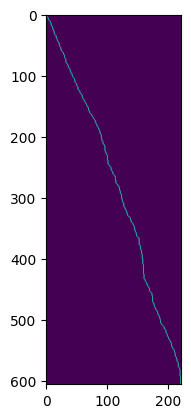

In [45]:
from matplotlib import pyplot as plt
plt.imshow(attn.cpu().detach().numpy()[0][0])
plt.show()

DEBUG:matplotlib.colorbar:locator: <matplotlib.ticker.AutoLocator object at 0x3416abee0>


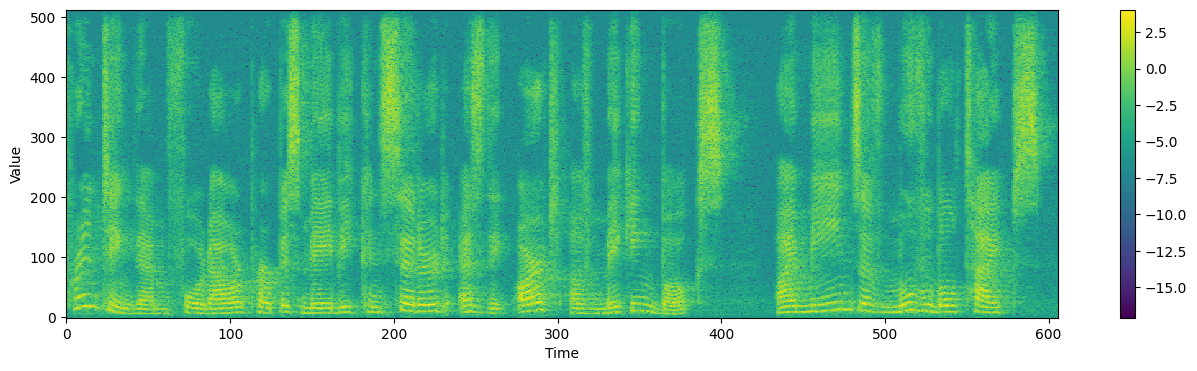

In [42]:
plot_spectrogram(np.log(spec))

In [43]:
display(Audio(y_hat.cpu().detach().numpy().reshape(-1), rate=hps.data.sampling_rate))

In [46]:
mel = spec_to_mel_torch(
    spec,
    hps.data.filter_length,
    hps.data.n_mel_channels,
    hps.data.sampling_rate,
    hps.data.mel_fmin,
    hps.data.mel_fmax)
y_mel = commons.slice_segments(mel, ids_slice, hps.train.segment_size // hps.data.hop_length)
y_hat_mel = mel_spectrogram_torch(
    y_hat.squeeze(1),
    hps.data.filter_length,
    hps.data.n_mel_channels,
    hps.data.sampling_rate,
    hps.data.hop_length,
    hps.data.win_length,
    hps.data.mel_fmin,
    hps.data.mel_fmax
)

DEBUG:matplotlib.colorbar:locator: <matplotlib.ticker.AutoLocator object at 0x342c17640>


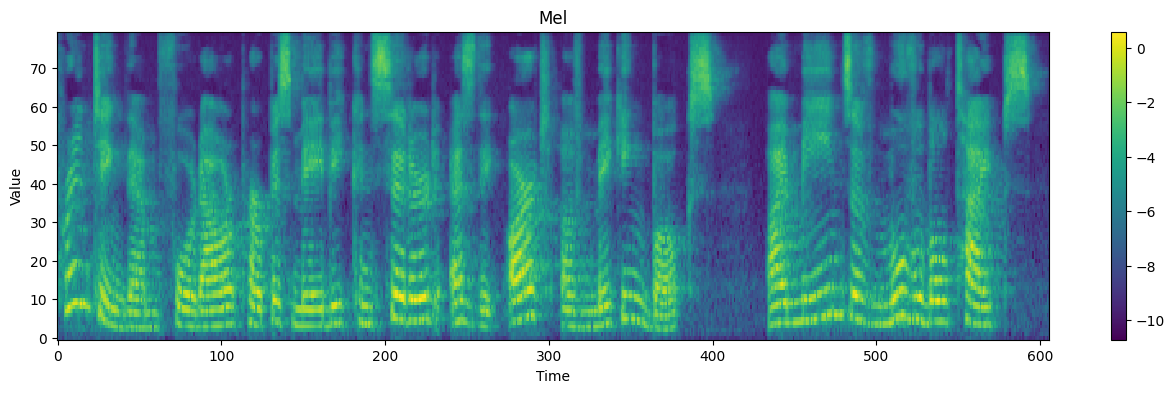

DEBUG:matplotlib.colorbar:locator: <matplotlib.ticker.AutoLocator object at 0x323fec250>


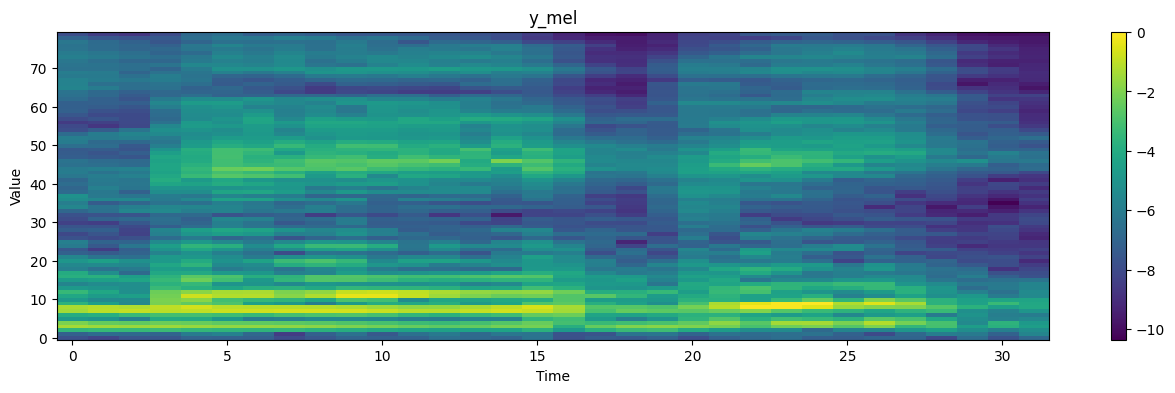

DEBUG:matplotlib.colorbar:locator: <matplotlib.ticker.AutoLocator object at 0x3240cca90>


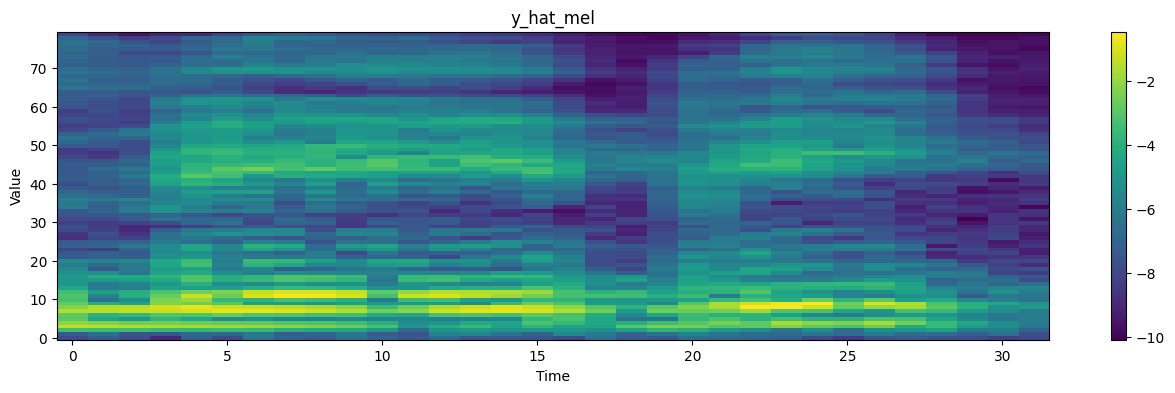

In [48]:
plot_spectrogram(mel, text="Mel")
plot_spectrogram(y_mel, text="y_mel")
plot_spectrogram(y_hat_mel, text="y_hat_mel")

In [49]:
y = commons.slice_segments(y, ids_slice * hps.data.hop_length, hps.train.segment_size)  # slice

# Discriminator
y_d_hat_r, y_d_hat_g, _, _ = net_d(y, y_hat.detach())

loss_disc, losses_disc_r, losses_disc_g = discriminator_loss(y_d_hat_r, y_d_hat_g)

In [50]:
# Generator
y_d_hat_r, y_d_hat_g, fmap_r, fmap_g = net_d(y, y_hat)
        
loss_dur = torch.sum(l_length.float())
loss_mel = F.l1_loss(y_mel, y_hat_mel) * hps.train.c_mel
loss_kl = kl_loss(z_p, logs_q, m_p, logs_p, z_mask) * hps.train.c_kl

loss_fm = feature_loss(fmap_r, fmap_g)
loss_gen, losses_gen = generator_loss(y_d_hat_g)
loss_gen_all = loss_gen + loss_fm + loss_mel + loss_dur + loss_kl

# Inference

In [51]:
# Inference
_ = net_g.eval()
_ = net_d.eval()
with torch.no_grad():
    x_tst = stn_tst.unsqueeze(0)
    x_tst_lengths = torch.LongTensor([[stn_tst.size(0)]])
    audio = net_g.infer(x_tst, x_tst_lengths, noise_scale=.667, noise_scale_w=0.8, length_scale=1)[0][
        0, 0].data.cpu().float().numpy()

In [52]:
display(Audio(audio, rate=hps.data.sampling_rate))
display(Audio(audio_norm, rate=hps.data.sampling_rate))